# 08 — Calculate equity delta

Calculate equity spot sensitivity for cash, futures, options and index positions.

Equity delta measures the INR value response to the underlying share or index. The bucket is regulatory; the exact factor is the named underlying.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display
from frtb_engine.notebook_tools import (
    INR_CRORE, bar_crore, bar_inr, configure_notebooks, crore_table,
    draw_capital_map, draw_flow, heatmap, percent_columns, display_sample,
)

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
print(f'Calculation run used in this notebook: {RUN_ID}')

Calculation run used in this notebook: SA_20260908T033903126517Z


This is the part of the calculation chain being handled here:

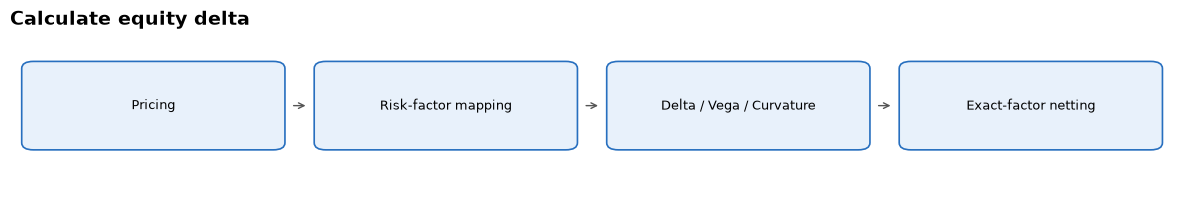

In [2]:
draw_flow(['Pricing', 'Risk-factor mapping', 'Delta / Vega / Curvature', 'Exact-factor netting'],'Calculate equity delta',wrap_after=4)

Apply a 1% relative spot bump, reprice, and divide the value change by 0.01.

$$s_k=\frac{V(S_k\times1.01)-V(S_k)}{0.01}$$

In [3]:
from frtb_engine.parameters import risk_weight
delta=pd.read_csv(RUN/'03_delta_trade_level.csv')
view=delta[delta.risk_class=='EQUITY'].copy()
view['value_change_for_bump_inr']=view.shocked_value_inr-view.base_value_inr
view['bump_unit']=np.where(view.relative,'1% relative move','1 basis point')
view['applicable_risk_weight']=view.apply(lambda row:risk_weight(row.to_dict(),'DELTA'),axis=1)
view['tenor_display']=view.apply(
    lambda row:f"{row.tenor:g} years" if pd.notna(row.tenor)
    else 'Not applicable for this risk factor',axis=1)
columns=['trade_id','instrument_type','currency','risk_class','bucket','risk_factor_id','tenor_display',
         'bump_unit','applicable_risk_weight','base_value_inr','shocked_value_inr','value_change_for_bump_inr','raw_sensitivity']
shown=crore_table(view[columns],['base_value_inr','shocked_value_inr','value_change_for_bump_inr','raw_sensitivity'])
display_sample(percent_columns(shown,['applicable_risk_weight']),25)
print('The risk weight is shown for reference. Formal weighting happens after exact-factor netting in Notebook 18.')
example=view.iloc[0]
print(f"Worked trade: {example.trade_id} | factor: {example.risk_factor_id}")
print(f"Base value: INR {example.base_value_inr/INR_CRORE:,.4f} crore")
print(f"Shocked value: INR {example.shocked_value_inr/INR_CRORE:,.4f} crore")
print(f"Value change for bump: INR {example.value_change_for_bump_inr:,.2f}")
print(f"Sensitivity = value change / bump = INR {example.raw_sensitivity:,.2f} per unit change")

Displayed rows: first 10 of 10 observations, in table order.


,trade_id,instrument_type,currency,risk_class,bucket,risk_factor_id,tenor_display,bump_unit,Applicable Risk Weight (%),Base Value (INR crore),Shocked Value (INR crore),Value Change For Bump (INR crore),Raw Sensitivity (INR crore per unit change)
59,E01,EQUITY_CASH,INR,EQUITY,3,RELIANCE,Not applicable for this risk factor,1% relative move,45.0000,29.8000,30.0980,0.2980,29.8000
61,E02,EQUITY_FUTURE,INR,EQUITY,3,RELIANCE,Not applicable for this risk factor,1% relative move,45.0000,-0.2175,-0.4261,-0.2086,-20.8600
63,E03,EQUITY_OPTION,INR,EQUITY,3,RELIANCE,Not applicable for this risk factor,1% relative move,45.0000,1.3522,1.4414,0.0892,8.9176
64,E04,EQUITY_CASH,INR,EQUITY,4,HDFC_BANK,Not applicable for this risk factor,1% relative move,55.0000,13.9200,14.0592,0.1392,13.9200
65,E05,EQUITY_CASH,INR,EQUITY,4,INFOSYS,Not applicable for this risk factor,1% relative move,55.0000,11.2800,11.3928,0.1128,11.2800
66,E06,EQUITY_CASH,INR,EQUITY,9,INDIA_SMALLCAP,Not applicable for this risk factor,1% relative move,70.0000,6.3000,6.3630,0.0630,6.3000
67,E07,EQUITY_CASH,USD,EQUITY,8,APPLE,Not applicable for this risk factor,1% relative move,50.0000,9.2665,9.3592,0.0927,9.2665
70,E08,EQUITY_FUTURE,INR,EQUITY,13,NIFTY50,Not applicable for this risk factor,1% relative move,25.0000,0.6629,1.1579,0.4950,49.5000
72,E09,EQUITY_OPTION,INR,EQUITY,13,NIFTY50,Not applicable for this risk factor,1% relative move,25.0000,-1.9304,-2.0926,-0.1623,-16.2253
74,E10,BARRIER_OPTION,INR,EQUITY,13,NIFTY50,Not applicable for this risk factor,1% relative move,25.0000,0.4535,0.4441,-0.0094,-0.9362


The risk weight is shown for reference. Formal weighting happens after exact-factor netting in Notebook 18.
Worked trade: E01 | factor: RELIANCE
Base value: INR 29.8000 crore
Shocked value: INR 30.0980 crore
Value change for bump: INR 2,980,000.00
Sensitivity = value change / bump = INR 298,000,000.00 per unit change


The visual below uses the calculated rows shown above.

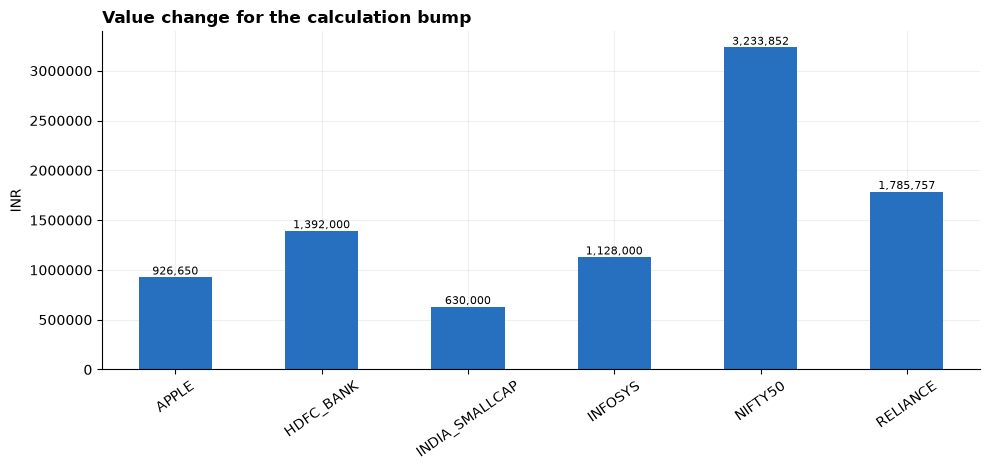

In [4]:
bar_inr(view.groupby('risk_factor_id')['value_change_for_bump_inr'].sum(),'Value change for the calculation bump')

Cash, futures and option deltas can offset only when their complete factor keys match.